In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [3]:
stocks = ["NVDA", "AAPL", "TSLA", "MSFT"]

future_days = 365
time_step = 60

results = []

In [5]:
for ticker in stocks:

    print("\n======================")
    print("Processing:", ticker)
    print("======================")


Processing: NVDA

Processing: AAPL

Processing: TSLA

Processing: MSFT


In [19]:
ticker = "NVDA"

data = yf.download(
    ticker,
    start="2018-01-01",
    end="2024-01-01"
)

print(len(data))
print(data.head())

[*********************100%***********************]  1 of 1 completed

1509
Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2018-01-02  4.928531  4.932240  4.808625  4.840270  355616000
2018-01-03  5.252899  5.283308  5.037314  5.045967  914704000
2018-01-04  5.280589  5.390854  5.258338  5.334238  583268000
2018-01-05  5.325337  5.362669  5.218534  5.295422  580124000
2018-01-08  5.488510  5.562679  5.403957  5.448953  881216000


In [21]:
data = data[["Close"]]

print(data.head())

Price          Close
Ticker          NVDA
Date                
2018-01-02  4.928531
2018-01-03  5.252899
2018-01-04  5.280589
2018-01-05  5.325337
2018-01-08  5.488510


In [23]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    data.values
)

print(scaled.shape)

(1509, 1)


In [25]:
X = []
y = []

for i in range(time_step, len(scaled)):

    X.append(
        scaled[i-time_step:i, 0]
    )

    y.append(
        scaled[i, 0]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)

(1449, 60)


In [27]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)

(1159, 60, 1)


In [29]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(time_step, 1)
    )
)

model.add(LSTM(50))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

print("Model ready")

Model ready


C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.0289
Epoch 2/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.0158e-04
Epoch 3/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 6.8748e-04
Epoch 4/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 5.5468e-04
Epoch 5/5
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 4.5260e-04


In [33]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)

y_real = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print(pred[:5])

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
[[12.994683 ]
 [13.116152 ]
 [13.253991 ]
 [13.4042225]
 [13.571123 ]]


In [35]:
mae = mean_absolute_error(
    y_real,
    pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_real,
        pred
    )
)

r2 = r2_score(
    y_real,
    pred
)

accuracy = 100 - (
    mae /
    np.mean(y_real)
    * 100
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Accuracy:", accuracy)

MAE: 2.307797139266442
RMSE: 3.005212034014912
R2: 0.9399020980259066
Accuracy: 93.14997704045626


In [37]:
stocks = [
    "AAPL",
    "NVDA",
    "MSFT",
    "GOOGL"
]

future_days = 365
results = []

In [39]:
for symbol in stocks:

    print("Processing", symbol)

    df = yf.download(
        symbol,
        start="2015-01-01",
        end="2023-12-31"
    )

    df = df[["Close"]]

    df.dropna(inplace=True)

    if len(df) < 200:
        print("Not enough data")
        continue


    scaler = MinMaxScaler()

    scaled = scaler.fit_transform(df)


    X = []
    y = []

    time_step = 60

    for i in range(time_step, len(scaled)):

        X.append(scaled[i-time_step:i, 0])
        y.append(scaled[i, 0])


    X = np.array(X)
    y = np.array(y)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )


    model = Sequential()

    model.add(
        LSTM(
            50,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(LSTM(50))

    model.add(Dense(1))


    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )


    model.fit(
        X,
        y,
        epochs=5,
        batch_size=32,
        verbose=0
    )


    last_data = scaled[-60:]

    temp = last_data.tolist()

    future = []


    for i in range(future_days):

        x = np.array(temp[-60:])
        x = x.reshape(1,60,1)

        pred = model.predict(x, verbose=0)

        temp.append(pred[0].tolist())

        future.append(pred[0])


    future = scaler.inverse_transform(future)


    last_price = df.iloc[-1,0]

    future_price = future[-1][0]


    results.append([
        symbol,
        last_price,
        future_price
    ])

Processing AAPL


[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing NVDA


[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing MSFT


[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Processing GOOGL


[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
result_df = pd.DataFrame(
    results,
    columns=[
        "Stock",
        "Last Price 2023",
        "Predicted Price 2024"
    ]
)

result_df

,Stock,Last Price 2023,Predicted Price 2024
0,AAPL,190.550461,199.165015
1,NVDA,49.494423,34.786736
2,MSFT,369.671875,352.087084
3,GOOGL,138.642471,113.974244


In [46]:
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


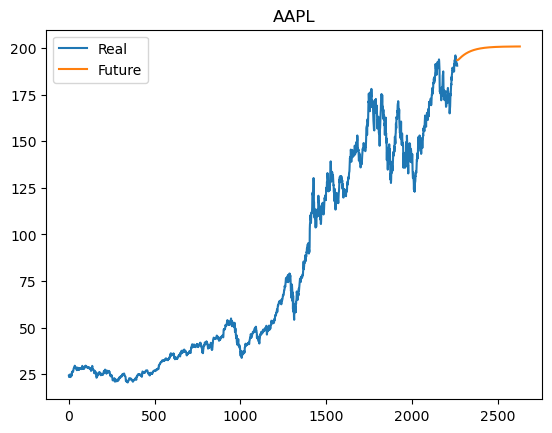

[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


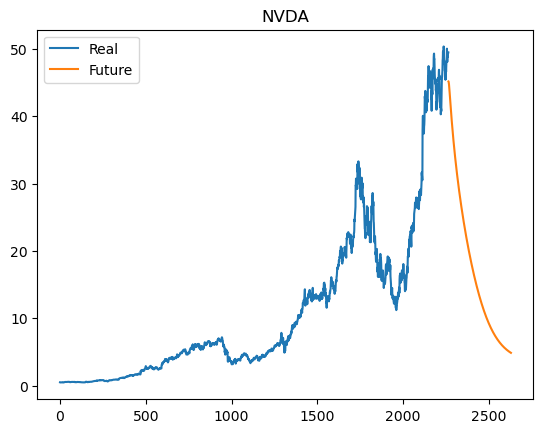

[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


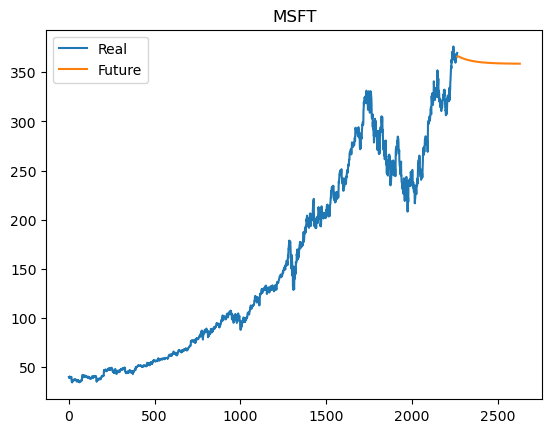

[*********************100%***********************]  1 of 1 completed
C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


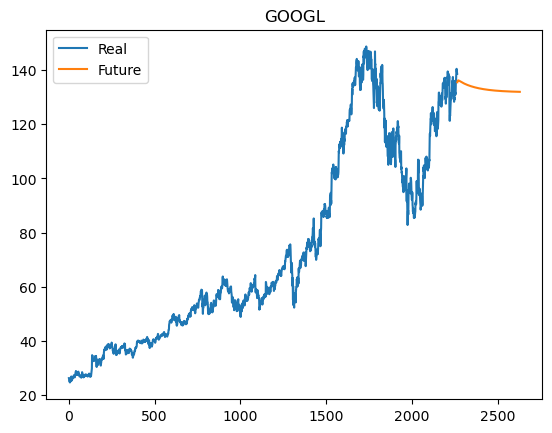

In [50]:
for symbol in stocks:

    df = yf.download(
        symbol,
        start="2015-01-01",
        end="2023-12-31"
    )

    df = df[["Close"]]

    df.dropna(inplace=True)

    scaler = MinMaxScaler()

    scaled = scaler.fit_transform(df)


    X = []
    y = []

    time_step = 60

    for i in range(time_step, len(scaled)):

        X.append(scaled[i-time_step:i, 0])
        y.append(scaled[i, 0])


    X = np.array(X)
    y = np.array(y)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )


    model = Sequential()

    model.add(
        LSTM(
            50,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(LSTM(50))

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )

    model.fit(
        X,
        y,
        epochs=3,
        batch_size=32,
        verbose=0
    )


    last_data = scaled[-60:]

    temp = last_data.tolist()

    future = []

    future_days = 365

    for i in range(future_days):

        x = np.array(temp[-60:])
        x = x.reshape(1,60,1)

        pred = model.predict(x, verbose=0)

        temp.append(pred[0].tolist())

        future.append(pred[0])


    future = scaler.inverse_transform(future)


    plt.figure()

    plt.plot(df.values, label="Real")

    future_plot = np.empty((len(df)+future_days,1))
    future_plot[:] = np.nan

    future_plot[len(df):] = future

    plt.plot(future_plot, label="Future")

    plt.title(symbol)

    plt.legend()

    plt.show()

## Prediction Result

This graph shows real price and future prediction using LSTM.

Blue = real price  
Orange = predicted future

In [54]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

In [56]:
metrics_results = []

In [58]:
for symbol in stocks:

    print("Evaluate", symbol)

    df = yf.download(
        symbol,
        start="2015-01-01",
        end="2023-12-31"
    )

    df = df[["Close"]]

    df.dropna(inplace=True)

    scaler = MinMaxScaler()

    scaled = scaler.fit_transform(df)


    X = []
    y = []

    time_step = 60

    for i in range(time_step, len(scaled)):

        X.append(scaled[i-time_step:i, 0])
        y.append(scaled[i, 0])


    X = np.array(X)
    y = np.array(y)

    X = X.reshape(
        X.shape[0],
        X.shape[1],
        1
    )


    split = int(len(X) * 0.8)

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]


    model = Sequential()

    model.add(
        LSTM(
            50,
            return_sequences=True,
            input_shape=(60,1)
        )
    )

    model.add(LSTM(50))

    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mean_squared_error"
    )


    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        verbose=0
    )


    pred = model.predict(X_test)

    pred = scaler.inverse_transform(pred.reshape(-1,1))

    real = scaler.inverse_transform(y_test.reshape(-1,1))


    mae = mean_absolute_error(real, pred)

    rmse = np.sqrt(
        mean_squared_error(real, pred)
    )

    r2 = r2_score(real, pred)


    accuracy = 100 - (mae / np.mean(real) * 100)


    metrics_results.append([
        symbol,
        mae,
        rmse,
        r2,
        accuracy
    ])

[*********************100%***********************]  1 of 1 completed

Evaluate AAPL



C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


[*********************100%***********************]  1 of 1 completed

...

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


[*********************100%***********************]  1 of 1 completed

Evaluate GOOGL



C:\Users\ivanf\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


In [60]:
metrics_df = pd.DataFrame(
    metrics_results,
    columns=[
        "Stock",
        "MAE",
        "RMSE",
        "R2",
        "Accuracy %"
    ]
)

metrics_df

,Stock,MAE,RMSE,R2,Accuracy %
0,AAPL,6.301135,7.309435,0.846716,96.078514
1,NVDA,1.502785,1.968830,0.976905,94.608367
2,MSFT,9.279512,11.497602,0.929473,96.722819
3,GOOGL,4.192565,5.129179,0.889032,96.301092


# Model Evaluation

This project uses LSTM to predict stock prices.

Evaluation metrics:

MAE = Mean Absolute Error  
RMSE = Root Mean Square Error  
R2 = R squared score  
Accuracy = custom accuracy formula  

Formula:

Accuracy = 100 - (MAE / mean price * 100)

Stocks used:

AAPL
NVDA
MSFT
GOOGL

Dataset:
Yahoo Finance

Period:
2015–2023

Prediction:
Future 1 year